# A Note on how to use Notebook Environments

To run a cell, press shift + enter. The notebook will execute the code in the cell and move to the next cell. If the cell contains a markdown cell (text only), it will render the markdown and move to the next cell.
Since cells can be executed in any order and variables can be over-written, you may at some point feel that you have lost track of the state of your notebook. If this is the case, you can always restart the kernel by clicking Runtime in the menu bar (if you're using Colab) and selecting Restart runtime. This will clear all variables and outputs.
The final variable in a cell will be printed on the screen. If you want to print multiple variables, use the print() function.
Notebook environments support code cells and markdown (text) cells. For the purposes of this workshop, markdown cells are used to provide high-level explanations of the code. More specific details are provided in the code cells themselves in the form of comments (lines beginning with #).


# Fitting a Reinforcement Learning Model to Choice Data

This notebook fits a simple reinforcement learning (RL) model to binary choice data — the same model used in research on probability learning in children and adults.

---

### The task

On each trial, a participant chooses between two options: a **high-probability option** (H) and a **low-probability option** (L). After choosing, they see the outcome for **both** options — this is called *counterfactual feedback* (they learn what they would have gotten had they chosen differently).

---

### The model

The model tracks an **expected value (EV)** for each option and updates it trial by trial.

**Update rule** — after each trial, *both* EVs are updated:  
> `EV_H(t) = EV_H(t-1) + α · (reward_H(t-1) − EV_H(t-1))`  
> `EV_L(t) = EV_L(t-1) + α · (reward_L(t-1) − EV_L(t-1))`

**Choice rule** — the probability of choosing H follows a logistic function:  
> `P(choose H) = 1 / (1 + exp(−θ · (EV_H − EV_L)))`

**Two free parameters:**
| Parameter | Symbol | Range | Meaning |
|-----------|--------|-------|---------|
| Learning rate | α (alpha) | 0 – 1 | How quickly EVs track new outcomes. α=0: no learning; α=1: only last trial matters |
| Inverse temperature | θ (theta) | 0 – 10 | How consistently the higher-EV option is chosen. θ≈0: random; θ=10: near-deterministic |

In [5]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive")

# Change working directory
%cd /content/drive/MyDrive/psybsc14

#load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(42)

Mounted at /content/drive
/content/drive/MyDrive/psybsc14


## Step 1 — Load data

We load a CSV file where each row is one trial. The file must contain these columns:
- `participant_id` — a unique number for each participant
- `trial` — trial number within a participant
- `choice` — 1 if the participant chose the high-probability option (H), 0 for low (L)
- `reward_H` — reward observed at the high option on that trial (0 or 1)
- `reward_L` — reward observed at the low option on that trial (0 or 1)

In [13]:
#load data (this is simulated data, not from real participants)

df = pd.read_csv('simulated_rl_data.csv')

print(f"Participants : {df['participant_id'].nunique()}")
print(f"Trials each  : {df.groupby('participant_id').size().unique()}")
print()
print(df.head())

Participants : 100
Trials each  : [100]

   participant_id  trial  choice  reward_H  reward_L  alpha_true  theta_true
0               1      1       1         1         0    0.732187    7.316635
1               1      2       1         0         1    0.732187    7.316635
2               1      3       0         1         0    0.732187    7.316635
3               1      4       1         1         1    0.732187    7.316635
4               1      5       1         1         0    0.732187    7.316635


## Step 2 — Define the model: negative log-likelihood

To find the best-fitting parameters, we measure how well a given parameter pair (α, θ) explains the participant's actual choices. We do this by computing the **log-likelihood** — the log probability of the observed choice sequence under the model.

On each trial, the model predicts the probability for choosing the high-probability option `P(choose H)`. For simplicity, we call this option H. If the participant chose H, that probability is good; if they chose L, `1 − P(choose H)` is what we want. We sum the log of these probabilities across all trials.

We actually minimise the *negative* log-likelihood (NLL), because standard optimisers minimise by default.

In [7]:
def neg_log_likelihood(params, choices, reward_H, reward_L):
    """
    Negative log-likelihood of the choice sequence given (alpha, theta).
    Lower = better fit.
    """
    alpha, theta = params

    # Return a large penalty if the optimiser wanders outside valid ranges
    # alpha should be in (0, 1) and theta should be positive but below some reasonable upper bound (e.g., 10)
    if not (0 < alpha < 1) or not (0 < theta < 10):
        return 1e10

    evH, evL = 0.0, 0.0   # initial expected values are set to zero: participants start with no prior knowledge about the options
    nll = 0.0 # initialize negative log-likelihood

    for t in range(len(choices)): # carry out the programming code for each trial
        # Predicted probability of choosing H
        # softmax function to convert expected value difference into choice probability
        # (evH-evL) describes how much better option H is compared to L based on current expected values. A larger difference means H is more attractive.
        # theta controls how strongly the expected value difference influences choice probabilities: higher theta means more deterministic choices, while lower theta means more random choices
        p_choose_H = 1 / (1 + np.exp(-theta * (evH - evL)))

        # Log-probability of the observed choice
        if choices[t] == 1: # if the participant chose H, we add the log-probability of choosing H to the negative log-likelihood
            nll -= np.log(p_choose_H + 1e-10) # adds a small constant to avoid log(0) which would be undefined
        else: # if the participant chose L, we add the log-probability of choosing L (which is 1 - p_choose_H) to the negative log-likelihood
            nll -= np.log(1 - p_choose_H + 1e-10) # adds a small constant to avoid log(0)

        # Update both expected values using counterfactual feedback (i.e., we update evH based on reward_H and evL based on reward_L, regardless of the actual choice)
        # This means that participants learn not only from the outcome of their chosen option but also from the outcome of the unchosen option, which is a key feature of counterfactual learning.
        # The learning rate alpha determines how much the expected values are updated based on the prediction error (the difference between the received reward and the current expected value).
        # A higher alpha means that participants update their beliefs more strongly based on new information.
        evH = evH + alpha * (reward_H[t] - evH)
        evL = evL + alpha * (reward_L[t] - evL)

    return nll

## Step 3 — Fit the model

We loop over participants. For each one, we extract their trial data and run the optimiser to find the (α, θ) that best explains their choices.

We use `scipy.optimize.minimize` with 10 random starting points per participant to avoid getting stuck in a local minimum.

What is the mean value for the fitted learning rate (alpha) and inverse temperature (theta)?

In [14]:
bounds = [(1e-4, 1 - 1e-4),   # alpha: between 0 and 1
          (1e-4, 10 - 1e-4)]  # theta: between 0 and 10

results = []

for pid, pdata in df.groupby('participant_id'):
    pdata = pdata.sort_values('trial')   # make sure trials are in order

    choices_p  = pdata['choice'].values
    reward_H_p = pdata['reward_H'].values
    reward_L_p = pdata['reward_L'].values

    best = None
    for _ in range(10):   # 10 random starting points per participant
        x0 = [rng.uniform(0.01, 0.99),
              rng.uniform(0.1,  9.9)]
        res = minimize(
            neg_log_likelihood,
            x0=x0,
            args=(choices_p, reward_H_p, reward_L_p),
            method='L-BFGS-B',
            bounds=bounds,
        )
        if best is None or res.fun < best.fun:
            best = res

    results.append({
        'participant_id': pid,
        'alpha_fit': best.x[0],
        'theta_fit': best.x[1],
        'nll': best.fun,
    })

results_df = pd.DataFrame(results)
print(results_df.describe().round(3))

       participant_id  alpha_fit  theta_fit      nll
count         100.000    100.000    100.000  100.000
mean           50.500      0.436      5.789   42.062
std            29.011      0.309      3.634   20.455
min             1.000      0.000      0.000   14.143
25%            25.750      0.127      2.458   20.746
50%            50.500      0.518      5.570   39.274
75%            75.250      0.714     10.000   62.535
max           100.000      1.000     10.000   69.315


## Step 4 — Visualise fitted parameters across participants

Each dot is one participant. Do you think there are distinct groups of participants who make choices fundamentally differently?

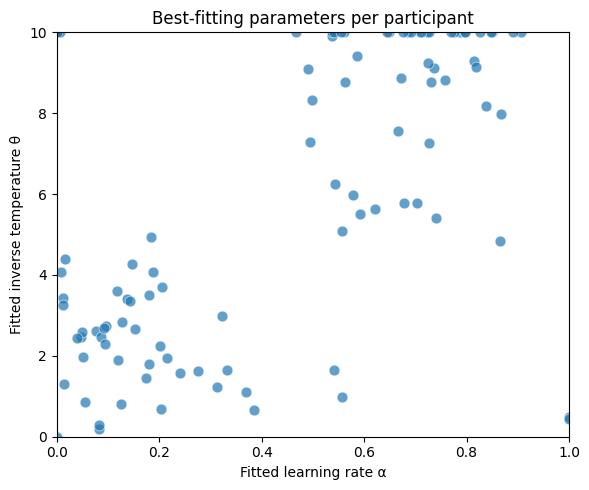

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(results_df['alpha_fit'], results_df['theta_fit'],
           alpha=0.7, edgecolors='white', linewidths=0.5, s=60)

ax.set_xlabel('Fitted learning rate α')
ax.set_ylabel('Fitted inverse temperature θ')
ax.set_title('Best-fitting parameters per participant')
ax.set_xlim(0, 1)
ax.set_ylim(0, 10)
plt.tight_layout()
plt.show()

## Step 5 — Visualise the likelihood surface for one participant

We pick a single participant and plot the NLL across the full parameter space. The white cross shows where the optimiser found the best fit.

How would you interpret this participant's best fitting parameters (e.g., do they learn quickly, how deterministically do they choose the higher valued option)? Look at the visualization for a different participant. Are they the same?

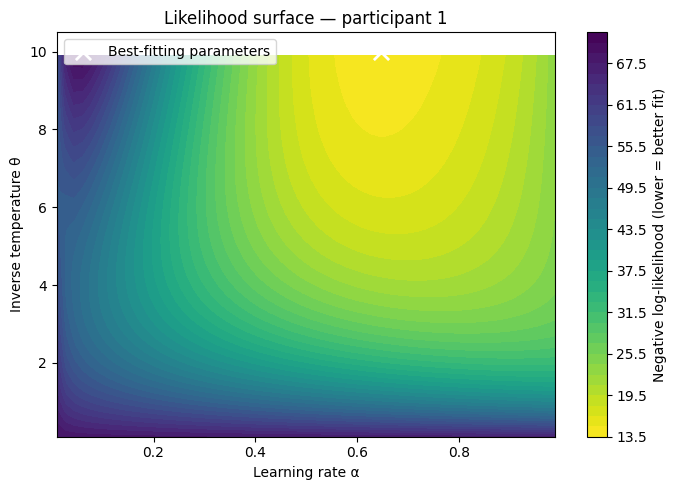

In [16]:
# Change this number to look at a different participant
EXAMPLE_PID = 1

pdata = df[df['participant_id'] == EXAMPLE_PID].sort_values('trial')
choices_ex  = pdata['choice'].values
reward_H_ex = pdata['reward_H'].values
reward_L_ex = pdata['reward_L'].values

alpha_ex = results_df.loc[results_df['participant_id'] == EXAMPLE_PID, 'alpha_fit'].values[0]
theta_ex = results_df.loc[results_df['participant_id'] == EXAMPLE_PID, 'theta_fit'].values[0]

alphas = np.linspace(0.01, 0.99, 60)
thetas = np.linspace(0.1,  9.9,  60)
AA, TT = np.meshgrid(alphas, thetas)

NLL = np.array([
    neg_log_likelihood([a, t], choices_ex, reward_H_ex, reward_L_ex)
    for a, t in zip(AA.ravel(), TT.ravel())
]).reshape(AA.shape)

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(AA, TT, NLL, levels=40, cmap='viridis_r')
plt.colorbar(cf, ax=ax, label='Negative log-likelihood (lower = better fit)')
ax.scatter([alpha_ex], [theta_ex],
           color='white', marker='x', s=120, linewidths=2,
           zorder=5, label='Best-fitting parameters')
ax.set_xlabel('Learning rate α')
ax.set_ylabel('Inverse temperature θ')
ax.set_title(f'Likelihood surface — participant {EXAMPLE_PID}')
ax.legend()
plt.tight_layout()
plt.show()